<div style="padding:34px 36px; border-radius:18px; background:linear-gradient(135deg,#123A63 0%,#176B87 58%,#1FA187 100%); color:white; margin-bottom:22px; box-shadow:0 8px 24px rgba(18,58,99,.18);">
  <div style="font-size:13px; letter-spacing:2px; font-weight:700; opacity:.88;">CUADERNO 3 · PREDICCIÓN Y POC</div>
  <h1 style="margin:10px 0 8px 0; font-size:36px; color:white;">Reconocimiento multilabel de instrumentos quirúrgicos</h1>
  <p style="font-size:18px; margin:0; opacity:.94;">Función de predicción, conclusiones y prototipo web</p>
  <div style="margin-top:22px; font-size:15px;"><b>Estudiantes:</b> Madeleine Arévalo, Tatiana Aucapiña y Esteban Tuquiñagui &nbsp;&nbsp;|&nbsp;&nbsp; <b>Año:</b> 2026</div>
</div>

### Propósito del cuaderno

Este cuaderno utiliza el modelo entrenado en el Cuaderno 2 para reconocer uno o varios instrumentos quirúrgicos en imágenes nuevas. Su contenido responde a los siguientes apartados de la práctica:

| Apartado | Desarrollo |
|---|---|
| **1.4** | Función propia de predicción multilabel |
| **1.5** | Conclusiones y referencias en formato APA 7 |
| **1.6** | Aplicación web como prueba de concepto (POC) |

El modelo posee cuatro salidas sigmoides independientes. Por tanto, una imagen puede recibir varias etiquetas positivas simultáneamente.

> **Alcance:** este sistema es un prototipo académico. No reemplaza el conteo protocolizado del instrumental ni la verificación realizada por profesionales de salud.

### Índice

1. [Configuración de clases y umbrales](#1-configuración-de-clases-y-umbrales)
2. [Carga y verificación del modelo](#2-carga-y-verificación-del-modelo-h5)
3. [Función propia de predicción](#3-función-propia-de-predicción-multilabel--apartado-14)
4. [Prueba con imágenes nuevas](#4-prueba-con-imágenes-nuevas)
5. [Prototipo del sistema inteligente](#5-prototipo-del-sistema-inteligente-poc--apartado-16)
6. [Conclusiones](#6-conclusiones--apartado-15)
7. [Referencias](#7-referencias-en-formato-apa-7)

## Flujo general de inferencia

| Etapa | Operación | Resultado |
|---:|---|---|
| 1 | Carga del modelo `.h5` | Modelo listo para inferencia |
| 2 | Conversión de la imagen a RGB | Entrada con tres canales |
| 3 | Generación de tres vistas | Original, reflejo y recorte central |
| 4 | Redimensionamiento | Imágenes de `224 × 224` píxeles |
| 5 | Predicción sigmoide | Probabilidad independiente por clase |
| 6 | Aplicación de umbrales | Instrumentos detectados |

La probabilidad final de cada instrumento corresponde al valor máximo obtenido entre la imagen original, el reflejo horizontal y el recorte central del 85 %.

> **Importante:** el modelo incluye internamente una capa `Rescaling` que transforma los píxeles de `[0, 255]` a `[-1, 1]`. Por ello, el cuaderno no divide nuevamente la imagen para 255; hacerlo produciría una doble normalización.

In [1]:
# En Google Colab, TensorFlow ya viene instalado.
# Solo se actualiza Gradio para construir la interfaz web.
%pip -q install -U "gradio>=5.0,<6" "pillow>=10"

from pathlib import Path
from IPython.display import display, Markdown
from PIL import Image, ImageOps

import json
import sys

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

try:
    from google.colab import files
    EN_COLAB = True
except ImportError:
    files = None
    EN_COLAB = False

print("TensorFlow:", tf.__version__)
print("Gradio:", gr.__version__)
print("Entorno:", "Google Colab" if EN_COLAB else "Jupyter local")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.3.0 requires starlette<2,>=1.0.1, but you have starlette 0.52.1 which is incompatible.
google-genai 2.10.0 requires pydantic<3.0.0,>=2.12.5, but you have pydantic 2.12.3 which is incompatible.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have g

---

## 1. Configuración de clases y umbrales

El orden de las etiquetas debe coincidir exactamente con las cuatro neuronas de salida del modelo. Los umbrales se obtuvieron exclusivamente con el conjunto de validación del Cuaderno 2.

| Índice | Instrumento | Umbral |
|---:|---|---:|
| 0 | Bisturí n.º 4 | 0.57 |
| 1 | Pinza de disección recta | 0.70 |
| 2 | Tijera Mayo recta | 0.59 |
| 3 | Tijera Mayo curva | 0.48 |

> Los umbrales no deben modificarse utilizando imágenes de prueba, porque esto introduciría sesgo en la evaluación.

In [2]:
CLASS_NAMES = [
    "Bisturí n.º 4",
    "Pinza de disección recta",
    "Tijera Mayo recta",
    "Tijera Mayo curva",
]

THRESHOLDS = np.array(
    [0.57, 0.70, 0.59, 0.48],
    dtype=np.float32,
)

IMG_SIZE = (224, 224)
NUM_CLASSES = len(CLASS_NAMES)

tabla_configuracion = pd.DataFrame(
    {
        "Índice de salida": range(NUM_CLASSES),
        "Instrumento": CLASS_NAMES,
        "Umbral": THRESHOLDS,
    }
)

display(tabla_configuracion.style.format({"Umbral": "{:.2f}"}))

,Índice de salida,Instrumento,Umbral
0,0,Bisturí n.º 4,0.57
1,1,Pinza de disección recta,0.70
2,2,Tijera Mayo recta,0.59
3,3,Tijera Mayo curva,0.48


---

## 2. Carga y verificación del modelo `.h5`

### Uso en Google Colab

1. Ejecuta la celda.
2. Selecciona `modelo_instrumentos_multilabel.h5` cuando aparezca el explorador.
3. Comprueba que la entrada sea `(None, 224, 224, 3)` y la salida `(None, 4)`.

Si el archivo ya se encuentra en `/content`, el código lo localizará automáticamente. En Jupyter local, coloca el `.h5` en la misma carpeta del cuaderno.

> Esta verificación evita utilizar por error un modelo con diferente tamaño de entrada o número de clases.

In [3]:
def localizar_modelo_h5():
    """Localiza un .h5 existente o solicita su carga en Google Colab."""

    carpetas = [Path.cwd()]
    if EN_COLAB:
        carpetas.insert(0, Path("/content"))

    candidatos = []
    for carpeta in carpetas:
        if carpeta.exists():
            candidatos.extend(carpeta.glob("*.h5"))

    if candidatos:
        preferidos = [
            ruta for ruta in candidatos
            if "modelo_instrumentos_multilabel" in ruta.name.lower()
        ]
        return (preferidos or candidatos)[0]

    if not EN_COLAB:
        raise FileNotFoundError(
            "No se encontró un archivo .h5. Colócalo junto al cuaderno y vuelve a ejecutar."
        )

    print("Selecciona el archivo modelo_instrumentos_multilabel.h5")
    archivos_modelo = files.upload()
    archivos_h5 = [nombre for nombre in archivos_modelo if nombre.lower().endswith(".h5")]

    if not archivos_h5:
        raise FileNotFoundError("No se seleccionó ningún archivo .h5.")

    return Path("/content") / archivos_h5[0]


RUTA_MODELO = localizar_modelo_h5()
MODELO = tf.keras.models.load_model(str(RUTA_MODELO), compile=False)

if tuple(MODELO.input_shape[1:]) != (*IMG_SIZE, 3):
    raise ValueError(
        f"El modelo espera {MODELO.input_shape}, pero el cuaderno fue configurado para "
        f"(None, {IMG_SIZE[0]}, {IMG_SIZE[1]}, 3)."
    )

if int(MODELO.output_shape[-1]) != NUM_CLASSES:
    raise ValueError(
        f"El modelo tiene {MODELO.output_shape[-1]} salidas y se esperaban {NUM_CLASSES}."
    )

print("MODELO CARGADO Y VERIFICADO")
print("Archivo:", RUTA_MODELO.name)
print("Entrada:", MODELO.input_shape)
print("Salida:", MODELO.output_shape)
print("Clases:", NUM_CLASSES)

Selecciona el archivo modelo_instrumentos_multilabel.h5


Saving modelo_instrumentos_multilabel.h5 to modelo_instrumentos_multilabel.h5
MODELO CARGADO Y VERIFICADO
Archivo: modelo_instrumentos_multilabel.h5
Entrada: (None, 224, 224, 3)
Salida: (None, 4)
Clases: 4


---

## 3. Función propia de predicción multilabel — apartado 1.4

La función `predecir_instrumentos()` recibe una ruta, una imagen PIL o un arreglo NumPy y ejecuta el flujo completo de inferencia. Además de devolver las probabilidades, ahora genera un estado explícito para la interfaz:

- `DETECCION`: al menos una clase supera su umbral.
- `SIN_DETECCIONES`: ninguna clase supera su umbral.
- `mensaje`: texto listo para comunicar el resultado al usuario.

### Información devuelta

| Campo | Interpretación |
|---|---|
| `Original` | Probabilidad de la imagen sin transformación |
| `Flip horizontal` | Probabilidad del reflejo horizontal |
| `Recorte central` | Probabilidad del recorte del 85 % |
| `Probabilidad final` | Máximo obtenido entre las tres vistas |
| `Umbral` | Valor mínimo definido para cada clase |
| `Margen` | Diferencia entre probabilidad y umbral |
| `Detectado` | Decisión multilabel final |
| `Acuerdo de vistas` | Porcentaje de vistas que superaron el umbral |
| `estado` | Resultado general de la inferencia |
| `mensaje` | Mensaje descriptivo para la POC |

Cuando ninguna clase supera su umbral, la función no fuerza una etiqueta: informa claramente que **no se encontraron instrumentos reconocidos**.

El uso de varias vistas constituye *test-time augmentation* (TTA). Esta técnica no cambia los pesos del modelo ni equivale a un nuevo entrenamiento.

In [4]:
def convertir_a_pil(entrada):
    """Convierte una ruta, imagen PIL o arreglo NumPy en una imagen RGB."""

    if isinstance(entrada, (str, Path)):
        imagen = Image.open(entrada)
    elif isinstance(entrada, Image.Image):
        imagen = entrada.copy()
    else:
        arreglo = np.asarray(entrada)

        if arreglo.ndim not in (2, 3):
            raise ValueError(
                "La entrada debe ser una imagen 2D o 3D válida."
            )

        if arreglo.dtype != np.uint8:
            arreglo = np.clip(arreglo, 0, 255).astype(np.uint8)

        imagen = Image.fromarray(arreglo)

    return ImageOps.exif_transpose(imagen).convert("RGB")


def generar_vistas(imagen, proporcion_recorte=0.85):
    """Genera la imagen original, un reflejo horizontal y un recorte central."""

    if not 0 < proporcion_recorte <= 1:
        raise ValueError("La proporción de recorte debe estar entre 0 y 1.")

    ancho, alto = imagen.size
    nuevo_ancho = max(1, int(ancho * proporcion_recorte))
    nuevo_alto = max(1, int(alto * proporcion_recorte))
    izquierda = (ancho - nuevo_ancho) // 2
    superior = (alto - nuevo_alto) // 2

    recorte = imagen.crop(
        (izquierda, superior, izquierda + nuevo_ancho, superior + nuevo_alto)
    )

    return {
        "Original": imagen,
        "Flip horizontal": ImageOps.mirror(imagen),
        "Recorte central": recorte,
    }


def predecir_instrumentos(entrada, mostrar=False):
    """
    Ejecuta la predicción multilabel completa.

    La probabilidad final de cada clase es el máximo entre tres vistas.
    Si ninguna clase supera su umbral, la función devuelve explícitamente
    el estado ``SIN_DETECCIONES`` y no asigna una etiqueta forzada.
    """

    if entrada is None:
        raise ValueError("No se recibió ninguna imagen para analizar.")

    imagen = convertir_a_pil(entrada)

    if imagen.width < 20 or imagen.height < 20:
        raise ValueError(
            "La imagen es demasiado pequeña. Utiliza una imagen de al menos 20 × 20 píxeles."
        )

    vistas = generar_vistas(imagen)

    lote = np.stack(
        [
            np.asarray(
                vista.resize(IMG_SIZE[::-1], Image.Resampling.BILINEAR),
                dtype=np.float32,
            )
            for vista in vistas.values()
        ],
        axis=0,
    )

    probabilidades_vistas = np.asarray(
        MODELO.predict(lote, verbose=0),
        dtype=np.float32,
    )

    if probabilidades_vistas.shape != (3, NUM_CLASSES):
        raise RuntimeError(
            f"Se esperaba una matriz (3, {NUM_CLASSES}) y se obtuvo "
            f"{probabilidades_vistas.shape}."
        )

    probabilidades_finales = probabilidades_vistas.max(axis=0)
    detectados = probabilidades_finales >= THRESHOLDS
    acuerdo = (probabilidades_vistas >= THRESHOLDS).mean(axis=0) * 100

    tabla = pd.DataFrame(
        {
            "Instrumento": CLASS_NAMES,
            "Original": probabilidades_vistas[0],
            "Flip horizontal": probabilidades_vistas[1],
            "Recorte central": probabilidades_vistas[2],
            "Probabilidad final": probabilidades_finales,
            "Umbral": THRESHOLDS,
            "Margen": probabilidades_finales - THRESHOLDS,
            "Detectado": detectados,
            "Acuerdo de vistas": acuerdo,
        }
    ).sort_values(
        "Probabilidad final",
        ascending=False,
    ).reset_index(drop=True)

    instrumentos = tabla.loc[
        tabla["Detectado"],
        "Instrumento",
    ].tolist()

    mejor_fila = tabla.iloc[0]
    hay_detecciones = bool(instrumentos)

    if hay_detecciones:
        estado = "DETECCION"
        cantidad = len(instrumentos)
        mensaje = (
            f"Se detectó {cantidad} instrumento."
            if cantidad == 1
            else f"Se detectaron {cantidad} instrumentos."
        )
    else:
        estado = "SIN_DETECCIONES"
        mensaje = (
            "No se encontraron instrumentos reconocidos dentro de los "
            "umbrales de decisión configurados."
        )

    resultado = {
        "imagen": imagen,
        "tabla": tabla,
        "instrumentos_detectados": instrumentos,
        "hay_detecciones": hay_detecciones,
        "estado": estado,
        "mensaje": mensaje,
        "mejor_candidato": str(mejor_fila["Instrumento"]),
        "probabilidad_maxima": float(mejor_fila["Probabilidad final"]),
        "umbral_mejor_candidato": float(mejor_fila["Umbral"]),
        "probabilidades_vistas": probabilidades_vistas,
    }

    if mostrar:
        mostrar_resultado(resultado)

    return resultado


def crear_grafica(resultado):
    """Crea una gráfica profesional de probabilidades y umbrales."""

    tabla = resultado["tabla"].sort_values(
        "Probabilidad final",
        ascending=True,
    )

    colores = [
        "#0F766E" if valor else "#CBD5E1"
        for valor in tabla["Detectado"]
    ]

    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    posiciones = np.arange(len(tabla))

    ax.barh(
        posiciones,
        tabla["Probabilidad final"],
        color=colores,
        height=0.58,
    )
    ax.scatter(
        tabla["Umbral"],
        posiciones,
        color="#DC2626",
        marker="|",
        s=290,
        linewidths=3,
        label="Umbral de decisión",
        zorder=3,
    )

    for posicion, probabilidad in zip(
        posiciones,
        tabla["Probabilidad final"],
    ):
        ax.text(
            min(probabilidad + 0.02, 0.96),
            posicion,
            f"{probabilidad:.1%}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#0F172A",
        )

    ax.set_yticks(posiciones, tabla["Instrumento"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probabilidad estimada")
    ax.set_title(
        "Probabilidad por clase frente al umbral de decisión",
        fontweight="bold",
    )
    ax.grid(axis="x", alpha=0.18)
    ax.legend(loc="lower right", frameon=False)

    for borde in ("top", "right", "left"):
        ax.spines[borde].set_visible(False)

    fig.tight_layout()
    return fig


def mostrar_resultado(resultado):
    """Muestra la imagen, el resumen, la gráfica y la tabla técnica."""

    instrumentos = resultado["instrumentos_detectados"]

    if instrumentos:
        resumen = ", ".join(instrumentos)
    else:
        resumen = "No se encontraron instrumentos reconocidos"

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    axes[0].imshow(resultado["imagen"])
    axes[0].axis("off")
    axes[0].set_title(resumen, fontweight="bold")

    tabla = resultado["tabla"].sort_values(
        "Probabilidad final",
        ascending=True,
    )
    posiciones = np.arange(len(tabla))
    colores = [
        "#0F766E" if valor else "#CBD5E1"
        for valor in tabla["Detectado"]
    ]

    axes[1].barh(
        posiciones,
        tabla["Probabilidad final"],
        color=colores,
    )
    axes[1].scatter(
        tabla["Umbral"],
        posiciones,
        color="#DC2626",
        marker="|",
        s=260,
        linewidths=3,
        label="Umbral",
    )
    axes[1].set_yticks(posiciones, tabla["Instrumento"])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probabilidad")
    axes[1].set_title("Probabilidades y umbrales", fontweight="bold")
    axes[1].legend(frameon=False)
    axes[1].grid(axis="x", alpha=0.2)

    fig.tight_layout()
    plt.show()

    formato = {
        "Original": "{:.2%}",
        "Flip horizontal": "{:.2%}",
        "Recorte central": "{:.2%}",
        "Probabilidad final": "{:.2%}",
        "Umbral": "{:.2f}",
        "Margen": "{:+.4f}",
        "Acuerdo de vistas": "{:.0f}%",
    }
    display(resultado["tabla"].style.format(formato))


print("Función predecir_instrumentos() creada correctamente.")

Función predecir_instrumentos() creada correctamente.


---

## 4. Prueba con imágenes nuevas

En Google Colab puedes seleccionar una o varias imágenes en formatos JPG, JPEG, PNG, BMP, TIFF o WEBP. Para cada archivo se presenta:

- la imagen original;
- los instrumentos reconocidos;
- una gráfica de probabilidades y umbrales;
- una tabla detallada de resultados.

En Jupyter local, reemplaza la lista `rutas_imagenes` por las rutas de tus archivos antes de ejecutar la celda.

Selecciona una o varias imágenes para realizar la predicción.


Saving tijera mayo curva.png to tijera mayo curva.png


### Resultado: `tijera mayo curva.png`

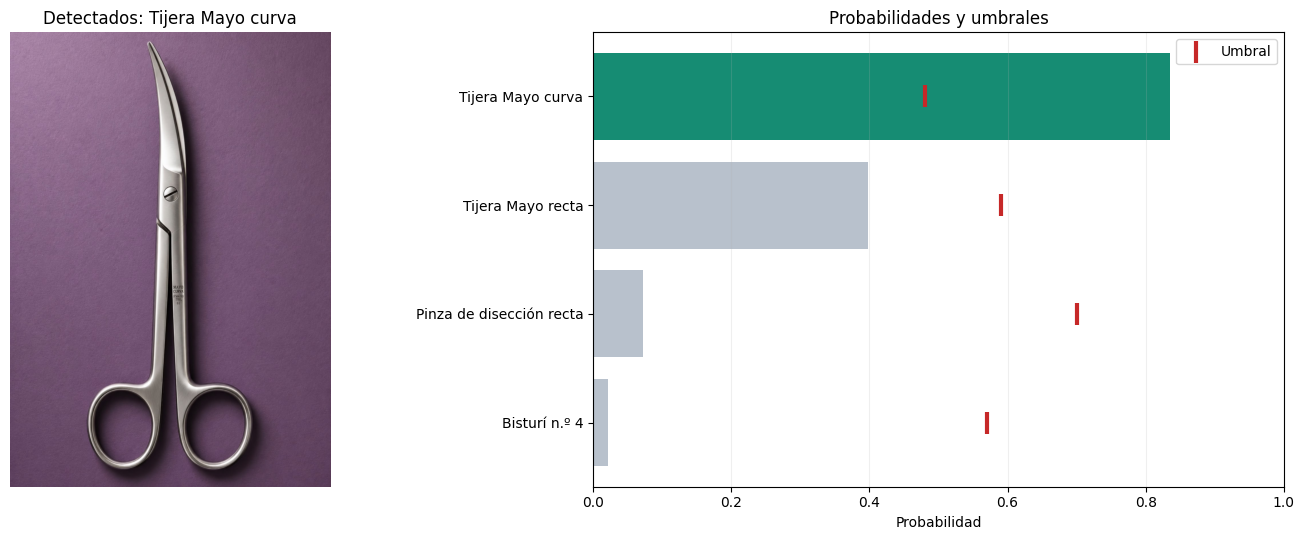

,Instrumento,Original,Flip horizontal,Recorte central,Probabilidad final,Umbral,Margen,Detectado,Acuerdo de vistas
0,Tijera Mayo curva,83.57%,76.16%,64.18%,83.57%,0.48,+0.3557,True,100%
1,Tijera Mayo recta,23.07%,26.94%,39.76%,39.76%,0.59,-0.1924,False,0%
2,Pinza de disección recta,0.48%,0.63%,7.29%,7.29%,0.70,-0.6271,False,0%
3,Bisturí n.º 4,1.53%,2.16%,1.42%,2.16%,0.57,-0.5484,False,0%


In [6]:
EXTENSIONES_VALIDAS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

if EN_COLAB:
    print("Selecciona una o varias imágenes para realizar la predicción.")
    archivos_imagen = files.upload()
    rutas_imagenes = [
        Path("/content") / nombre
        for nombre in archivos_imagen
        if Path(nombre).suffix.lower() in EXTENSIONES_VALIDAS
    ]
else:
    # Ejemplo local: rutas_imagenes = [Path("mi_imagen.jpg")]
    rutas_imagenes = []
    print("Modo local: agrega tus rutas a la lista rutas_imagenes y vuelve a ejecutar.")

if EN_COLAB and not rutas_imagenes:
    raise RuntimeError("No se seleccionó ninguna imagen válida.")

for ruta in rutas_imagenes:
    display(Markdown(f"### Resultado: `{ruta.name}`"))
    resultado = predecir_instrumentos(ruta, mostrar=True)

---

## 5. Prototipo del sistema inteligente (POC) — apartado 1.6

La POC se rediseñó con una apariencia más cercana a una aplicación comercial para un entorno de salud. La interfaz separa claramente la carga de la imagen, el estado del análisis, los resultados y la información técnica.

### Mejoras incorporadas

| Mejora | Implementación |
|---|---|
| Resultado sin detecciones | Mensaje visible: “No se encontraron instrumentos reconocidos” |
| Diseño profesional | Paleta clínica azul y verde, tarjetas, jerarquía visual y botones claros |
| Resumen ejecutivo | Número de instrumentos, mayor probabilidad y estado del análisis |
| Resultados interpretables | Etiquetas detectadas, probabilidad, umbral, margen y estabilidad |
| Manejo de errores | Mensajes comprensibles cuando falta una imagen o la entrada no es válida |
| Transparencia | Aviso permanente de que se trata de una POC académica |

> La interfaz no presenta el sistema como un dispositivo médico validado. Su finalidad es demostrar la integración funcional del modelo en una aplicación web.

In [7]:
import html


CSS_MEDICO = """
:root {
    --medical-navy: #0B2447;
    --medical-blue: #146C94;
    --medical-teal: #0F766E;
    --medical-mint: #E8F7F4;
    --medical-bg: #F4F7FA;
    --medical-border: #DCE5EC;
    --medical-text: #102A43;
    --medical-muted: #627D98;
    --medical-danger: #B42318;
}

.gradio-container {
    max-width: 1280px !important;
    margin: 0 auto !important;
    background: var(--medical-bg) !important;
    font-family: Inter, ui-sans-serif, system-ui, -apple-system, BlinkMacSystemFont,
                 "Segoe UI", sans-serif !important;
}

#app-header {
    background: linear-gradient(120deg, #0B2447 0%, #146C94 62%, #0F766E 100%);
    border-radius: 22px;
    padding: 28px 32px;
    margin: 8px 0 20px;
    color: white;
    box-shadow: 0 16px 38px rgba(11, 36, 71, 0.18);
}

.brand-row {
    display: flex;
    align-items: center;
    gap: 16px;
}

.brand-mark {
    width: 58px;
    height: 58px;
    min-width: 58px;
    display: grid;
    place-items: center;
    border-radius: 17px;
    background: rgba(255, 255, 255, 0.16);
    border: 1px solid rgba(255, 255, 255, 0.28);
    font-size: 21px;
    font-weight: 800;
    letter-spacing: -1px;
}

.brand-title {
    margin: 0;
    font-size: 30px;
    line-height: 1.1;
    color: white;
}

.brand-subtitle {
    margin: 7px 0 0;
    font-size: 15px;
    color: rgba(255, 255, 255, 0.88);
}

.header-badge {
    display: inline-block;
    margin-top: 18px;
    padding: 7px 11px;
    border-radius: 999px;
    background: rgba(255, 255, 255, 0.14);
    border: 1px solid rgba(255, 255, 255, 0.24);
    font-size: 12px;
    font-weight: 700;
    letter-spacing: .5px;
}

.medical-card {
    background: white !important;
    border: 1px solid var(--medical-border) !important;
    border-radius: 18px !important;
    padding: 18px !important;
    box-shadow: 0 8px 24px rgba(31, 55, 76, 0.07) !important;
}

.section-kicker {
    color: var(--medical-teal);
    font-size: 12px;
    font-weight: 800;
    text-transform: uppercase;
    letter-spacing: 1.2px;
    margin-bottom: 4px;
}

.section-title {
    color: var(--medical-navy);
    font-size: 21px;
    font-weight: 750;
    margin: 0 0 6px;
}

.section-copy {
    color: var(--medical-muted);
    font-size: 14px;
    margin-bottom: 14px;
}

#analyze-button {
    min-height: 48px;
    border-radius: 12px !important;
    font-weight: 750 !important;
    box-shadow: 0 8px 20px rgba(20, 108, 148, 0.18);
}

#clear-button {
    min-height: 48px;
    border-radius: 12px !important;
    font-weight: 700 !important;
}

.status-card {
    border-radius: 16px;
    padding: 18px 20px;
    border: 1px solid;
    margin-bottom: 14px;
}

.status-success {
    background: #ECFDF5;
    border-color: #A7F3D0;
    color: #065F46;
}

.status-empty {
    background: #F8FAFC;
    border-color: #CBD5E1;
    color: #334155;
}

.status-error {
    background: #FFF1F2;
    border-color: #FECDD3;
    color: #9F1239;
}

.status-idle {
    background: #EFF6FF;
    border-color: #BFDBFE;
    color: #1E3A8A;
}

.status-heading {
    font-size: 18px;
    font-weight: 800;
    margin: 0 0 6px;
}

.status-copy {
    font-size: 14px;
    margin: 0;
    line-height: 1.5;
}

.instrument-chip {
    display: inline-flex;
    align-items: center;
    margin: 10px 7px 0 0;
    padding: 8px 11px;
    border-radius: 999px;
    background: white;
    border: 1px solid #A7F3D0;
    font-size: 13px;
    font-weight: 750;
    color: #065F46;
}

.metrics-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 12px;
    margin: 0 0 16px;
}

.metric-card {
    background: white;
    border: 1px solid var(--medical-border);
    border-radius: 14px;
    padding: 14px;
}

.metric-label {
    color: var(--medical-muted);
    font-size: 12px;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: .5px;
}

.metric-value {
    color: var(--medical-navy);
    font-size: 22px;
    font-weight: 800;
    margin-top: 4px;
}

.metric-note {
    color: var(--medical-muted);
    font-size: 11px;
    margin-top: 2px;
}

.medical-note {
    padding: 13px 15px;
    border-radius: 12px;
    background: #F8FAFC;
    border: 1px solid var(--medical-border);
    color: var(--medical-muted);
    font-size: 13px;
    line-height: 1.5;
}

.footer-disclaimer {
    margin-top: 18px;
    padding: 14px 16px;
    border-radius: 14px;
    background: #FFF7ED;
    border: 1px solid #FED7AA;
    color: #9A3412;
    font-size: 13px;
    line-height: 1.5;
}

@media (max-width: 760px) {
    .metrics-grid {
        grid-template-columns: 1fr;
    }

    #app-header {
        padding: 22px;
    }

    .brand-title {
        font-size: 24px;
    }
}
"""


ENCABEZADO_HTML = """
<div id="app-header">
    <div class="brand-row">
        <div class="brand-mark">SV</div>
        <div>
            <h1 class="brand-title">SurgiVision AI</h1>
            <p class="brand-subtitle">
                Reconocimiento inteligente de instrumentos quirúrgicos
            </p>
        </div>
    </div>
    <div class="header-badge">PROTOTIPO ACADÉMICO · CLASIFICACIÓN MULTILABEL</div>
</div>
"""


ESTADO_INICIAL_HTML = """
<div class="status-card status-idle">
    <p class="status-heading">Sistema listo para analizar</p>
    <p class="status-copy">
        Carga una imagen del instrumental quirúrgico y selecciona
        <b>Analizar imagen</b>.
    </p>
</div>
"""


METRICAS_INICIALES_HTML = """
<div class="metrics-grid">
    <div class="metric-card">
        <div class="metric-label">Instrumentos detectados</div>
        <div class="metric-value">—</div>
        <div class="metric-note">Pendiente de análisis</div>
    </div>
    <div class="metric-card">
        <div class="metric-label">Mayor probabilidad</div>
        <div class="metric-value">—</div>
        <div class="metric-note">Pendiente de análisis</div>
    </div>
    <div class="metric-card">
        <div class="metric-label">Estado</div>
        <div class="metric-value">Listo</div>
        <div class="metric-note">Modelo cargado</div>
    </div>
</div>
"""


COLUMNAS_COMERCIALES = [
    "Instrumento",
    "Probabilidad",
    "Umbral",
    "Margen",
    "Resultado",
    "Estabilidad TTA",
]


def construir_estado_html(resultado):
    """Construye la tarjeta principal del resultado."""

    if resultado["hay_detecciones"]:
        chips = "".join(
            (
                '<span class="instrument-chip">'
                f'{html.escape(instrumento)}'
                "</span>"
            )
            for instrumento in resultado["instrumentos_detectados"]
        )

        return f"""
        <div class="status-card status-success">
            <p class="status-heading">Instrumentos reconocidos</p>
            <p class="status-copy">{html.escape(resultado["mensaje"])}</p>
            <div>{chips}</div>
        </div>
        """

    mejor = html.escape(resultado["mejor_candidato"])
    probabilidad = resultado["probabilidad_maxima"]
    umbral = resultado["umbral_mejor_candidato"]

    return f"""
    <div class="status-card status-empty">
        <p class="status-heading">No se encontraron instrumentos</p>
        <p class="status-copy">
            Ninguna de las cuatro clases superó su umbral de decisión.
            La mayor probabilidad correspondió a <b>{mejor}</b>
            ({probabilidad:.1%}), por debajo de su umbral ({umbral:.2f}).
        </p>
    </div>
    """


def construir_metricas_html(resultado):
    """Construye las tarjetas de resumen del análisis."""

    cantidad = len(resultado["instrumentos_detectados"])
    probabilidad = resultado["probabilidad_maxima"]

    if resultado["hay_detecciones"]:
        estado = "Detectado"
        nota_estado = "Resultado positivo"
    else:
        estado = "Sin hallazgos"
        nota_estado = "Ninguna clase superó el umbral"

    return f"""
    <div class="metrics-grid">
        <div class="metric-card">
            <div class="metric-label">Instrumentos detectados</div>
            <div class="metric-value">{cantidad}</div>
            <div class="metric-note">De {NUM_CLASSES} clases disponibles</div>
        </div>
        <div class="metric-card">
            <div class="metric-label">Mayor probabilidad</div>
            <div class="metric-value">{probabilidad:.1%}</div>
            <div class="metric-note">
                {html.escape(resultado["mejor_candidato"])}
            </div>
        </div>
        <div class="metric-card">
            <div class="metric-label">Estado</div>
            <div class="metric-value">{estado}</div>
            <div class="metric-note">{nota_estado}</div>
        </div>
    </div>
    """


def preparar_tabla_comercial(resultado):
    """Simplifica la tabla técnica para presentarla al usuario final."""

    tabla = resultado["tabla"].copy()

    tabla["Probabilidad"] = tabla["Probabilidad final"].map(
        lambda valor: f"{valor:.1%}"
    )
    tabla["Umbral"] = tabla["Umbral"].map(
        lambda valor: f"{valor:.2f}"
    )
    tabla["Margen"] = tabla["Margen"].map(
        lambda valor: f"{valor:+.3f}"
    )
    tabla["Resultado"] = tabla["Detectado"].map(
        {True: "Detectado", False: "No detectado"}
    )
    tabla["Estabilidad TTA"] = tabla["Acuerdo de vistas"].map(
        lambda valor: f"{valor:.0f}%"
    )

    return tabla[COLUMNAS_COMERCIALES]


def predecir_interfaz(imagen):
    """Conecta la función de inferencia con la interfaz Gradio."""

    if imagen is None:
        return (
            """
            <div class="status-card status-error">
                <p class="status-heading">No se recibió una imagen</p>
                <p class="status-copy">
                    Carga una fotografía válida antes de iniciar el análisis.
                </p>
            </div>
            """,
            METRICAS_INICIALES_HTML,
            pd.DataFrame(columns=COLUMNAS_COMERCIALES),
            None,
        )

    try:
        resultado = predecir_instrumentos(imagen)

        return (
            construir_estado_html(resultado),
            construir_metricas_html(resultado),
            preparar_tabla_comercial(resultado),
            crear_grafica(resultado),
        )

    except Exception as error:
        mensaje = html.escape(str(error))

        return (
            f"""
            <div class="status-card status-error">
                <p class="status-heading">No fue posible completar el análisis</p>
                <p class="status-copy">{mensaje}</p>
            </div>
            """,
            METRICAS_INICIALES_HTML,
            pd.DataFrame(columns=COLUMNAS_COMERCIALES),
            None,
        )


def limpiar_interfaz():
    """Restablece todos los componentes de la aplicación."""

    return (
        None,
        ESTADO_INICIAL_HTML,
        METRICAS_INICIALES_HTML,
        pd.DataFrame(columns=COLUMNAS_COMERCIALES),
        None,
    )


tema_medico = gr.themes.Soft(
    primary_hue="teal",
    secondary_hue="blue",
    neutral_hue="slate",
    radius_size="lg",
    font=[
        gr.themes.GoogleFont("Inter"),
        "ui-sans-serif",
        "system-ui",
        "sans-serif",
    ],
)


with gr.Blocks(
    title="SurgiVision AI",
    theme=tema_medico,
    css=CSS_MEDICO,
) as demo:

    gr.HTML(ENCABEZADO_HTML)

    with gr.Row(equal_height=True):

        with gr.Column(
            scale=5,
            elem_classes=["medical-card"],
        ):
            gr.HTML(
                """
                <div class="section-kicker">Paso 1</div>
                <div class="section-title">Cargar imagen</div>
                <div class="section-copy">
                    Utiliza una fotografía clara, centrada y con iluminación uniforme.
                </div>
                """
            )

            imagen_entrada = gr.Image(
                type="pil",
                image_mode="RGB",
                sources=["upload", "webcam", "clipboard"],
                label="Vista previa de la imagen",
                height=420,
            )

            with gr.Row():
                boton_analizar = gr.Button(
                    "Analizar imagen",
                    variant="primary",
                    elem_id="analyze-button",
                )
                boton_limpiar = gr.Button(
                    "Limpiar",
                    variant="secondary",
                    elem_id="clear-button",
                )

            gr.HTML(
                """
                <div class="medical-note">
                    <b>Recomendación:</b> evita imágenes borrosas, fondos con
                    objetos similares y oclusiones extensas. El modelo reconoce
                    únicamente las cuatro clases incluidas en su entrenamiento.
                </div>
                """
            )

        with gr.Column(
            scale=7,
            elem_classes=["medical-card"],
        ):
            gr.HTML(
                """
                <div class="section-kicker">Paso 2</div>
                <div class="section-title">Resultado del análisis</div>
                <div class="section-copy">
                    La decisión se obtiene comparando cada probabilidad con su
                    umbral específico.
                </div>
                """
            )

            estado_salida = gr.HTML(ESTADO_INICIAL_HTML)
            metricas_salida = gr.HTML(METRICAS_INICIALES_HTML)

            tabla_salida = gr.Dataframe(
                headers=COLUMNAS_COMERCIALES,
                datatype=["str"] * len(COLUMNAS_COMERCIALES),
                value=pd.DataFrame(columns=COLUMNAS_COMERCIALES),
                label="Resultados por instrumento",
                interactive=False,
                wrap=True,
            )

    with gr.Accordion(
        "Información técnica del análisis",
        open=False,
    ):
        gr.Markdown(
            """
            La barra representa la probabilidad final de cada clase. La marca roja
            indica el umbral que debe superarse para considerar una detección.
            """
        )
        grafica_salida = gr.Plot(
            label="Probabilidades y umbrales",
        )

    gr.HTML(
        """
        <div class="footer-disclaimer">
            <b>Aviso:</b> SurgiVision AI es una prueba de concepto académica.
            No constituye un dispositivo médico, no reemplaza el conteo manual
            protocolizado del instrumental y no debe utilizarse para tomar
            decisiones clínicas.
        </div>
        """
    )

    boton_analizar.click(
        fn=predecir_interfaz,
        inputs=imagen_entrada,
        outputs=[
            estado_salida,
            metricas_salida,
            tabla_salida,
            grafica_salida,
        ],
    )

    imagen_entrada.submit(
        fn=predecir_interfaz,
        inputs=imagen_entrada,
        outputs=[
            estado_salida,
            metricas_salida,
            tabla_salida,
            grafica_salida,
        ],
    )

    boton_limpiar.click(
        fn=limpiar_interfaz,
        inputs=[],
        outputs=[
            imagen_entrada,
            estado_salida,
            metricas_salida,
            tabla_salida,
            grafica_salida,
        ],
    )


demo.launch(
    share=EN_COLAB,
    debug=False,
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ad566668b39f4d9d8a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## 6. Conclusiones

1. Se implementó una función propia de inferencia que integra la carga de imágenes, su conversión a RGB, el redimensionamiento a `224 × 224`, la generación de tres vistas y la aplicación de umbrales específicos por clase. La función devuelve resultados interpretables y permite reconocer simultáneamente varios instrumentos.

2. La función distingue explícitamente entre los estados `DETECCION` y `SIN_DETECCIONES`. Cuando ninguna clase supera su umbral, el sistema no fuerza una etiqueta y comunica al usuario que no se encontraron instrumentos reconocidos dentro de los umbrales configurados.

3. La salida sigmoide de cuatro neuronas es coherente con la naturaleza multilabel del problema, porque la presencia de un instrumento no excluye la presencia de los demás. La decisión final se realiza de forma independiente para cada clase.

4. La inferencia multivista permite comprobar la estabilidad de la predicción frente a una reflexión horizontal y un recorte central. El máximo por clase favorece la sensibilidad del prototipo, mientras que el porcentaje de acuerdo ayuda a identificar predicciones menos consistentes.

5. La interfaz web fue rediseñada con una estructura más cercana a una aplicación comercial: carga guiada de imágenes, estado visible del análisis, tarjetas de resumen, tabla simplificada y visualización técnica desplegable. Esto facilita el uso del modelo por una persona que no necesita editar código.

6. El prototipo está limitado a las cuatro clases utilizadas durante el entrenamiento y realiza clasificación de la imagen completa; no localiza cada instrumento mediante cajas delimitadoras. Su desempeño puede disminuir ante fondos, iluminación, escalas, oclusiones o instrumentos diferentes a los observados en el conjunto de datos.

7. Antes de una utilización real se requiere validación externa con imágenes independientes, análisis de errores por clase, control de versiones del modelo y evaluación bajo condiciones representativas del entorno de uso. Esta POC es académica y no constituye un dispositivo médico.

### Limitaciones principales

- Solo reconoce las cuatro clases incluidas durante el entrenamiento.
- Clasifica la imagen completa y no determina la ubicación espacial de cada instrumento.
- Puede verse afectado por cambios de iluminación, fondo, orientación u oclusión.
- Una ausencia de detección no confirma que la imagen esté libre de instrumental; únicamente indica que ninguna clase superó el umbral configurado.
- Requiere validación externa antes de considerar una aplicación real.

---

## 7. Referencias en formato APA 7

Abadi, M., Barham, P., Chen, J., Chen, Z., Davis, A., Dean, J., Devin, M., Ghemawat, S., Irving, G., Isard, M., Kudlur, M., Levenberg, J., Monga, R., Moore, S., Murray, D. G., Steiner, B., Tucker, P., Vasudevan, V., Warden, P., ... Zheng, X. (2016). TensorFlow: A system for large-scale machine learning. En *12th USENIX Symposium on Operating Systems Design and Implementation (OSDI 16)* (pp. 265–283). USENIX Association. https://www.usenix.org/conference/osdi16/technical-sessions/presentation/abadi

Gradio Team. (s. f.). *Gradio documentation*. Recuperado el 15 de julio de 2026, de https://www.gradio.app/docs

Keras Team. (s. f.). *Keras 3 API documentation*. Recuperado el 15 de julio de 2026, de https://keras.io/api/

Lavado, D., da Silva, J., & Caramelo, F. (2018). *Labeled surgical tools and images* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/dilavado/labeled-surgical-tools

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. En *2018 IEEE/CVF Conference on Computer Vision and Pattern Recognition* (pp. 4510–4520). IEEE. https://doi.org/10.1109/CVPR.2018.00474